
=== Natural Gas Price LS Envelope ===
Region: West_South_Central (Texas proxy)
Fit window: 2025–2050  (n=26)
m_LOG = 1.77868,  m_HOG = 0.672863
Envelope multipliers: [0.672863, 1.77868]
Equivalent range vs reference: [-32.714%, 77.868%]

Year  ref_price   env_low   env_high   LOG_price   HOG_price
2025   2.702884  1.818671  4.807574   3.699224   2.218614
2026   2.602545  1.751157  4.629102   3.667104   2.059296
2027   2.549224  1.715279  4.534261   3.808350   2.033904
2028   2.701754  1.817911  4.805564   4.175693   2.178029
2029   2.910596  1.958433  5.177027   4.716477   2.279984
2030   3.163967  2.128917  5.627694   5.740700   2.440423
2031   3.303848  2.223038  5.876498   6.323299   2.544189
2032   3.843493  2.586145  6.836355   7.123114   2.843096
2033   4.214373  2.835696  7.496033   7.409045   2.926303
2034   4.409548  2.967022  7.843188   7.609113   2.959214
2035   4.425838  2.977983  7.872162   7.651300   2.990757
2036   4.374448  2.943405  7.780756   7.956063   2.995825
2037

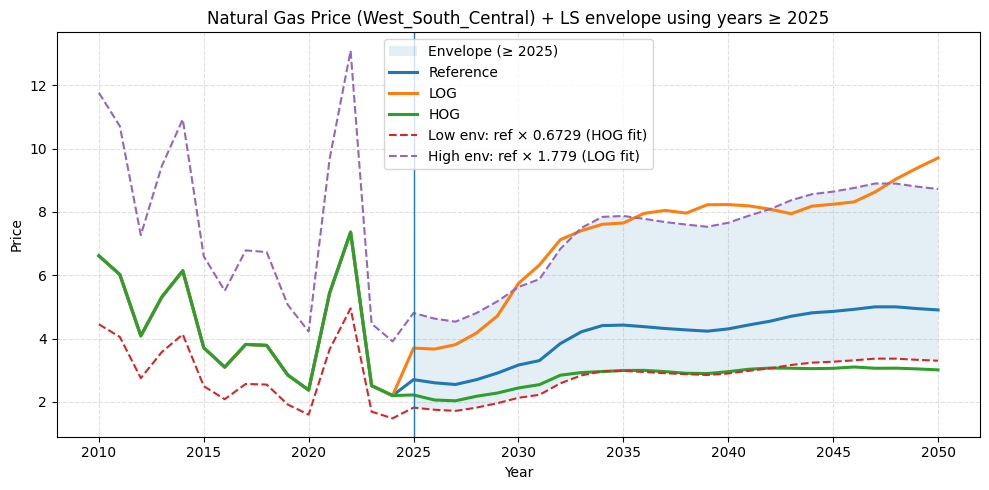

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def fit_multiplier_ls(ref: pd.Series, target: pd.Series) -> float:
    """Least-squares scalar m minimizing ||m*ref - target||^2 over aligned years."""
    x = ref.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(x, x))
    if denom == 0:
        return np.nan
    return float(np.dot(x, y) / denom)

def make_ng_df_from_urls(urls: dict, region_col: str = "West_South_Central") -> pd.DataFrame:
    """
    urls = {"reference": url, "LOG": url, "HOG": url}
    Returns long df: year, scenario, price
    """
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        if "year" not in df.columns:
            raise ValueError(f"'year' column not found in {scen} file. Columns: {list(df.columns)}")
        if region_col not in df.columns:
            raise ValueError(f"Region '{region_col}' not found in {scen} file. Columns: {list(df.columns)}")

        out = df[["year", region_col]].copy()
        out["year"] = out["year"].astype(int)
        out.rename(columns={region_col: "price"}, inplace=True)
        out["price"] = out["price"].astype(float)
        out["scenario"] = scen
        dfs.append(out)

    return pd.concat(dfs, ignore_index=True).sort_values(["year", "scenario"])

def envelope_ng_prices(df: pd.DataFrame, start_year: int = 2025) -> dict:
    """
    Reference is baseline; LOG and HOG are compared to reference.
    Envelope is reference * [low_mult, high_mult] from LS fit over years >= start_year.
    """
    piv = (df.pivot(index="year", columns="scenario", values="price")
             .sort_index())

    needed = ["reference", "LOG", "HOG"]
    missing = [s for s in needed if s not in piv.columns]
    if missing:
        raise ValueError(f"Missing scenarios: {missing}. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=needed, how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year}.")

    ref = window["reference"]
    m_log = fit_multiplier_ls(ref, window["LOG"])
    m_hog = fit_multiplier_ls(ref, window["HOG"])

    low_mult  = float(np.nanmin([m_log, m_hog]))
    high_mult = float(np.nanmax([m_log, m_hog]))
    low_ref   = "LOG" if m_log <= m_hog else "HOG"
    high_ref  = "LOG" if m_log >= m_hog else "HOG"

    return {
        "m_log": m_log,
        "m_hog": m_hog,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_ng_with_envelope(df: pd.DataFrame, region_col: str, start_year: int = 2025):
    info = envelope_ng_prices(df, start_year=start_year)

    piv = (df.pivot(index="year", columns="scenario", values="price")
             .sort_index())

    years = piv.index
    ref_all = piv["reference"]
    env_low  = ref_all * info["low_mult"]
    env_high = ref_all * info["high_mult"]

    mask = years >= start_year
    yrs = years[mask]

    # ---- Print ranges ----
    print("\n=== Natural Gas Price LS Envelope ===")
    print(f"Region: {region_col} (Texas proxy)")
    print(f"Fit window: {info['fit_year_min']}–{info['fit_year_max']}  (n={info['n_years_fit']})")
    print(f"m_LOG = {info['m_log']:.6g},  m_HOG = {info['m_hog']:.6g}")
    print(f"Envelope multipliers: [{info['low_mult']:.6g}, {info['high_mult']:.6g}]")
    print(f"Equivalent range vs reference: [{(info['low_mult']-1)*100:.3f}%, {(info['high_mult']-1)*100:.3f}%]")

    print("\nYear  ref_price   env_low   env_high   LOG_price   HOG_price")
    for y in yrs:
        log_v = piv.loc[y, "LOG"] if "LOG" in piv.columns else np.nan
        hog_v = piv.loc[y, "HOG"] if "HOG" in piv.columns else np.nan
        print(f"{int(y):4d}  {ref_all.loc[y]:9.6f}  {env_low.loc[y]:8.6f}  {env_high.loc[y]:8.6f}  "
              f"{log_v:9.6f}  {hog_v:9.6f}")

    print("\nEnvelope bounds over years ≥", start_year)
    print(f"env_low  min/max:  {env_low.loc[yrs].min():.6f} / {env_low.loc[yrs].max():.6f}")
    print(f"env_high min/max:  {env_high.loc[yrs].min():.6f} / {env_high.loc[yrs].max():.6f}")

    # ---- Plot (one graph only) ----
    plt.figure(figsize=(10, 5))

    plt.fill_between(
        yrs,
        env_low.loc[yrs].values,
        env_high.loc[yrs].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["reference"].values, linewidth=2.2, label="Reference")
    plt.plot(years, piv["LOG"].values, linewidth=2.2, label="LOG")
    plt.plot(years, piv["HOG"].values, linewidth=2.2, label="HOG")

    plt.plot(years, env_low.values, "--",
             label=f"Low env: ref × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(years, env_high.values, "--",
             label=f"High env: ref × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"Natural Gas Price ({region_col}) + LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel("Price")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info, piv, env_low, env_high


# ---------- Run ----------
urls = {
    "reference": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/fuelprices/ng_AEO_2025_reference.csv",
    "LOG":       "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/fuelprices/ng_AEO_2025_LOG.csv",
    "HOG":       "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/fuelprices/ng_AEO_2025_HOG.csv",
}

REGION_TEXAS = "West_South_Central"  # Texas proxy in this file
ng_tx = make_ng_df_from_urls(urls, region_col=REGION_TEXAS)

info_ng, piv_ng, envL_ng, envH_ng = plot_ng_with_envelope(
    ng_tx, region_col=REGION_TEXAS, start_year=2025
)



In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# CONFIG
# =========================
REGION_TEXAS = "West_South_Central"
START_YEAR = 2025

n_samples = 2
seed = 123
rng = np.random.default_rng(seed)

out_dir = Path("ng_sampling_outputs")
out_dir.mkdir(exist_ok=True)

# =========================
# 1) Make sure your reference URL is correct (you had a typo earlier)
# =========================
# If urls already exists in your notebook, this fixes only the reference if needed.
# Otherwise, define urls exactly as you use above.
if "urls" not in globals():
    raise NameError("I expected a dict named `urls` with keys: reference, LOG, HOG. Define it in your NG cell first.")

urls["reference"] = urls["reference"].replace("ReEDS-...0", "ReEDS-2.0")  # harmless if already correct

# =========================
# 2) Load FULL reference table (wide format) — this is the base we will modify
# =========================
df_ref_wide = pd.read_csv(urls["reference"])
df_ref_wide["year"] = df_ref_wide["year"].astype(int)

if REGION_TEXAS not in df_ref_wide.columns:
    raise ValueError(
        f"Column '{REGION_TEXAS}' not found in reference file. "
        f"Available columns: {list(df_ref_wide.columns)}"
    )

# Keep column order exactly like the GitHub file
col_order = list(df_ref_wide.columns)

# =========================
# 3) Pull envelope bounds from your existing envelope code outputs
# =========================
# In your NG notebook you computed something like:
#   info_ng, piv_ng, envL_ng, envH_ng = plot_ng_with_envelope(...)
# The `info_ng` dict contains the multipliers in your implementation.
#
# If your dict is named differently, set INFO = that dict.
#
# Try common names automatically:
INFO = None
for candidate in ["info_ng", "info_mult", "info", "ng_info"]:
    if candidate in globals() and isinstance(globals()[candidate], dict):
        if ("low_mult" in globals()[candidate]) and ("high_mult" in globals()[candidate]):
            INFO = globals()[candidate]
            break

if INFO is None:
    raise NameError(
        "Could not find your envelope info dict. "
        "Expected something like `info_ng` containing keys: 'low_mult' and 'high_mult'."
    )

low_bound = float(min(INFO["low_mult"], INFO["high_mult"]))
high_bound = float(max(INFO["low_mult"], INFO["high_mult"]))
print(f"Envelope scalar bounds (TX region scaling vs reference): [{low_bound:.6f}, {high_bound:.6f}]")

# =========================
# 4) Sample scalars within bounds + print list format
# =========================
sampled_scalars = rng.uniform(low_bound, high_bound, size=n_samples).tolist()

print("sampled_scalars = [")
for s in sampled_scalars:
    print(f"  {s:.8f},")
print("]")

# Save scalar record (optional but recommended)
pd.DataFrame({
    "sample_id": np.arange(1, n_samples + 1),
    "tx_scalar": sampled_scalars,
    "low_bound": low_bound,
    "high_bound": high_bound,
    "seed": seed,
    "start_year": START_YEAR,
    "region_modified": REGION_TEXAS
}).to_csv(out_dir / "West_South_Central_scalar_samples.csv", index=False)

# =========================
# 5) Generate ReEDS-format ng_AEO_2025 CSVs (wide), TX region only changes
# =========================
def make_ng_sample_file(sample_id: int, tx_scalar: float) -> Path:
    df_out = df_ref_wide.copy()

    # apply scaling only for years >= START_YEAR
    m = df_out["year"] >= START_YEAR
    df_out.loc[m, REGION_TEXAS] = df_out.loc[m, REGION_TEXAS].astype(float) * tx_scalar

    # enforce original column order
    df_out = df_out[col_order]

    fpath = out_dir / f"ng_AEO_2025_TXsample_{sample_id:03d}.csv"
    df_out.to_csv(fpath, index=False)
    return fpath

files = [make_ng_sample_file(i, s) for i, s in enumerate(sampled_scalars, start=1)]

print(f"\nGenerated {len(files)} files in: {out_dir.resolve()}")
print("Example file:", files[0])


Envelope scalar bounds (TX region scaling vs reference): [0.672863, 1.778683]
sampled_scalars = [
  1.42742132,
  0.73237951,
]

Generated 2 files in: /content/ng_sampling_outputs
Example file: ng_sampling_outputs/ng_AEO_2025_TXsample_001.csv


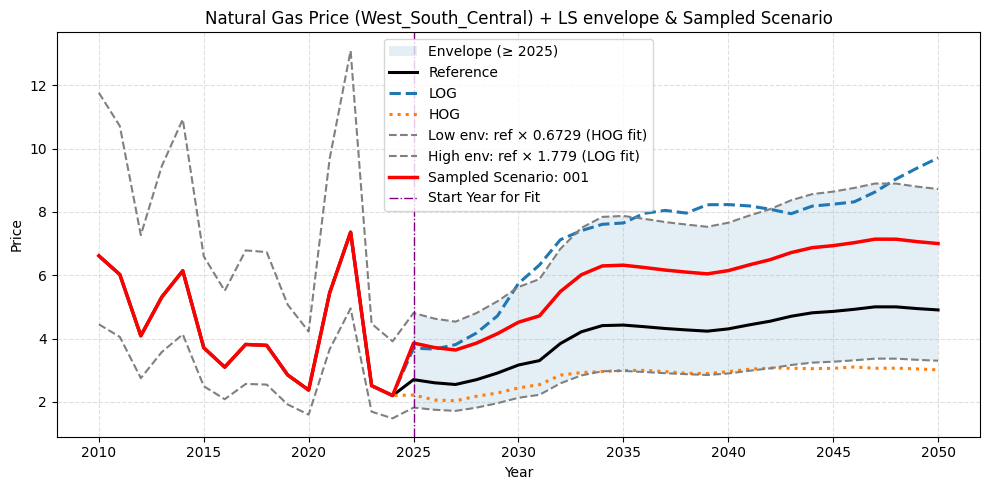

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the first sampled file
sample_file_path = files[0]
df_sample_wide = pd.read_csv(sample_file_path)
sample_series = df_sample_wide.set_index('year')[REGION_TEXAS]

# Get variables from previous execution
info = INFO
piv = piv_ng
env_low = envL_ng
env_high = envH_ng
start_year = START_YEAR
region_col = REGION_TEXAS

years = piv.index
mask = years >= start_year
yrs = years[mask]

plt.figure(figsize=(10, 5))

# Plot the envelope
plt.fill_between(
    yrs,
    env_low.loc[yrs].values,
    env_high.loc[yrs].values,
    alpha=0.12,
    label=f"Envelope (≥ {start_year})"
)

# Plot original scenarios
plt.plot(years, piv["reference"].values, linewidth=2.2, label="Reference", color='black')
plt.plot(years, piv["LOG"].values, linewidth=2.2, label="LOG", linestyle='--')
plt.plot(years, piv["HOG"].values, linewidth=2.2, label="HOG", linestyle=':')

# Plot envelope boundaries
plt.plot(years, env_low.values, "--", color='gray',
         label=f"Low env: ref × {info['low_mult']:.4g} ({info['low_ref']} fit)")
plt.plot(years, env_high.values, "--", color='gray',
         label=f"High env: ref × {info['high_mult']:.4g} ({info['high_ref']} fit)")

# Plot the sampled scenario
plt.plot(years, sample_series.loc[years].values, linewidth=2.5, color='red', label=f"Sampled Scenario: {sample_file_path.stem.split('_')[-1]}")

plt.axvline(start_year, linewidth=1, color='purple', linestyle='-.', label='Start Year for Fit')
plt.title(f"Natural Gas Price ({region_col}) + LS envelope & Sampled Scenario")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
from IPython.display import Markdown, display

# info_ng comes from: info_ng, piv_ng, envL_ng, envH_ng = plot_ng_with_envelope(...)
low_mult  = info_ng["low_mult"]
high_mult = info_ng["high_mult"]

latex_rows = []
latex_rows.append(
    rf"Natural gas price -- {REGION_TEXAS} & {high_mult:.4f} & {low_mult:.4f} & \$/MMBtu (multiplier) \\"
)

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Natural Gas Price Multiplier Bounds (LS envelope) for {REGION_TEXAS} (AEO 2025)}}
\label{{tab:ng_price_bounds_{REGION_TEXAS.lower()}}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))


```latex

\begin{table}[h!]
\centering
\caption{Natural Gas Price Multiplier Bounds (LS envelope) for West_South_Central (AEO 2025)}
\label{tab:ng_price_bounds_west_south_central}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Natural gas price -- West_South_Central & 1.7787 & 0.6729 & \$/MMBtu (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import zipfile

# ============================================================
# CONFIG (edit if you need)
# ============================================================
URL_NG_REF = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/fuelprices/ng_AEO_2025_reference.csv"

URL_MORRIS_DESIGN = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv"
URL_FACTOR_MAP    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv"

REGION_COL = "West_South_Central"   # Texas proxy column in ng file
START_YEAR = 2025                  # apply multipliers only for years >= this

OUTDIR = Path("ng_morris_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

ZIP_NAME = "ng_AEO_2025_West_South_Central_morris_r5_p6_200files.zip"


# ============================================================
# 1) READ NREL NG REFERENCE (WIDE) — DEFINES EXACT FORMAT
# ============================================================
df_ref = pd.read_csv(URL_NG_REF)

# Hard checks to avoid ReEDS errors
if "year" not in df_ref.columns:
    raise ValueError(f"'year' column not found in NG reference. Columns: {list(df_ref.columns)}")

df_ref["year"] = pd.to_numeric(df_ref["year"], errors="raise").astype(int)

if REGION_COL not in df_ref.columns:
    raise ValueError(
        f"Region column '{REGION_COL}' not found in NG reference file.\n"
        f"Available columns: {list(df_ref.columns)[:25]} ..."
    )

# Preserve EXACT column order as NREL reference
ref_cols = df_ref.columns.tolist()


# ============================================================
# 2) READ MORRIS DESIGN + FACTOR MAP
# ============================================================
design = pd.read_csv(URL_MORRIS_DESIGN)
factor_map = pd.read_csv(URL_FACTOR_MAP)

if "run_id" not in design.columns:
    raise ValueError(f"'run_id' not found in design file. Columns: {list(design.columns)}")

# Identify the factor column for NG price West_South_Central
# (match the parameter name you used in the combined bounds table)
mask = factor_map["Parameter"].astype(str).str.contains(
    "Natural gas price -- West_South_Central", case=False, regex=False
)

# fallback if you named it slightly differently
if mask.sum() != 1:
    mask = factor_map["Parameter"].astype(str).str.contains("Natural gas price", case=False, regex=False) & \
           factor_map["Parameter"].astype(str).str.contains("West_South_Central", case=False, regex=False)

if mask.sum() != 1:
    raise ValueError(
        "Could not uniquely identify the NG West_South_Central factor in morris_factor_map.csv.\n"
        f"Matches found: {int(mask.sum())}\n"
        "Tip: print(factor_map['Parameter'].unique()) and adjust the matching text."
    )

ng_factor = factor_map.loc[mask, "factor"].iloc[0]

if ng_factor not in design.columns:
    raise ValueError(
        f"NG factor '{ng_factor}' not found as a column in morris_design.\n"
        f"Design columns (first 25): {list(design.columns)[:25]} ..."
    )

print(f"Using Morris factor column for NG: {ng_factor}")


# ============================================================
# 3) GENERATE 200 FILES — EXACTLY LIKE NREL REFERENCE FORMAT
# ============================================================
csv_dir = OUTDIR / "csv"
csv_dir.mkdir(exist_ok=True)

generated_files = []

for _, row in design.iterrows():
    run_id = int(row["run_id"])
    scalar = float(row[ng_factor])

    df_out = df_ref.copy()

    # Apply scaling only for years >= START_YEAR, and ONLY for REGION_COL
    m = df_out["year"] >= START_YEAR
    df_out.loc[m, REGION_COL] = pd.to_numeric(df_out.loc[m, REGION_COL], errors="raise") * scalar

    # Enforce exact column order
    df_out = df_out[ref_cols]

    out_fp = csv_dir / f"ng_AEO_2025_{REGION_COL}_morris_{run_id:03d}.csv"
    df_out.to_csv(out_fp, index=False, float_format="%.6f")
    generated_files.append(out_fp)

print(f"Generated {len(generated_files)} CSV files in: {csv_dir.resolve()}")


# ============================================================
# 4) MANIFEST + ZIP
# ============================================================
manifest = OUTDIR / "manifest.csv"
manifest_df = pd.DataFrame({
    "run_id": design["run_id"].astype(int),
    "trajectory": design["trajectory"].astype(int) if "trajectory" in design.columns else np.nan,
    "step": design["step"].astype(int) if "step" in design.columns else np.nan,
    "ng_scalar": design[ng_factor].astype(float),
    "changed_factor": design["changed_factor"].astype(str) if "changed_factor" in design.columns else "",
})
manifest_df.to_csv(manifest, index=False)




Using Morris factor column for NG: natural_gas_price_west_south_central
Generated 200 CSV files in: /content/ng_morris_outputs/csv


In [6]:
from pathlib import Path
import shutil

OUT_DIR = Path("ng_morris_outputs/csv")  # <- must match your script
zip_name = "ng_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: ng_morris_outputs.zip
